# Лабораторная работа 6 — Отбор признаков

**Дисциплина:** Машинное обучение  
**Датасет:** GTZAN Genre Collection (features_30_sec.csv)  
**Библиотеки:** pandas, numpy, scikit-learn, matplotlib, seaborn

## Цель работы

Изучить и применить различные методы отбора признаков (feature selection) для снижения размерности датасета GTZAN и оценить влияние отбора на качество классификации.

## Теоретическое введение

### Зачем нужен отбор признаков?

При работе с данными высокой размерности возникает ряд проблем:
- **Проклятие размерности** — с ростом числа признаков объём данных, необходимый для обучения, растёт экспоненциально
- **Переобучение** — избыточные признаки могут содержать шум, на котором модель обучается вместо закономерностей
- **Вычислительные затраты** — больше признаков = дольше обучение
- **Интерпретируемость** — модель с меньшим числом признаков легче объяснить

### Категории методов отбора

**1. Фильтрующие методы (Filter)** — оценивают признаки независимо от модели:
- **Mutual Information** — измеряет количество информации, которое признак даёт о целевой переменной
- **Chi-squared** ($\chi^2$) — тест на независимость признака от целевой переменной
- **Дисперсия** — признаки с низкой дисперсией малоинформативны

**2. Обёрточные методы (Wrapper)** — используют модель для оценки подмножеств:
- **RFE** (Recursive Feature Elimination) — итеративно удаляет наименее важные признаки
- **Forward/Backward Selection** — последовательное добавление/удаление признаков

**3. Встроенные методы (Embedded)** — отбор в процессе обучения:
- **LASSO (L1)** — регуляризация обнуляет коэффициенты неважных признаков
- **Feature Importance** — встроенная оценка важности в ансамблевых моделях (Random Forest, Gradient Boosting)

### Консенсусный подход

Разные методы могут давать разные наборы признаков. **Консенсусный подход** — отбираем признаки, выбранные несколькими методами одновременно. Это повышает надёжность отбора.

## Загрузка и подготовка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.feature_selection import (
    mutual_info_classif, chi2, SelectKBest, RFE
)
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.ensemble import RandomForestClassifier
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Библиотеки загружены')

Библиотеки загружены


In [2]:
df = pd.read_csv('../../datasets/gtzan/features_30_sec.csv')
print(f'Размер: {df.shape}')

# Подготовка X и y
drop_cols = ['filename', 'length', 'label']
X = df.drop(columns=drop_cols)
feature_names = X.columns.tolist()

le = LabelEncoder()
y = le.fit_transform(df['label'])

print(f'Признаков: {X.shape[1]}')
print(f'Классы: {le.classes_}')


Размер: (1000, 60)
Признаков: 57
Классы: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']


In [3]:
# Стандартизация для методов, чувствительных к масштабу
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_names)

print('Средние:')
print(X_scaled.iloc[:, :5].mean())
print('\nStd:')
print(X_scaled.iloc[:, :5].std())

print(X_scaled.iloc[:, :5].describe())


# MinMaxScaler для Chi-squared (требует неотрицательные значения)
mm_scaler = MinMaxScaler()
X_positive = pd.DataFrame(mm_scaler.fit_transform(X), columns=feature_names)

print('Данные подготовлены')

Средние:
chroma_stft_mean         -4.831691e-16
chroma_stft_var          -1.882938e-15
rms_mean                 -4.973799e-16
rms_var                  -9.947598e-17
spectral_centroid_mean    1.563194e-16
dtype: float64

Std:
chroma_stft_mean          1.0005
chroma_stft_var           1.0005
rms_mean                  1.0005
rms_var                   1.0005
spectral_centroid_mean    1.0005
dtype: float64
       chroma_stft_mean  chroma_stft_var      rms_mean       rms_var  \
count      1.000000e+03     1.000000e+03  1.000000e+03  1.000000e+03   
mean      -4.831691e-16    -1.882938e-15 -4.973799e-16 -9.947598e-17   
std        1.000500e+00     1.000500e+00  1.000500e+00  1.000500e+00   
min       -2.531623e+00    -5.404508e+00 -1.913980e+00 -8.388031e-01   
25%       -7.239436e-01    -5.228113e-01 -6.743707e-01 -5.807743e-01   
50%        5.469008e-02     3.554380e-02 -1.292693e-01 -3.399581e-01   
75%        7.011661e-01     6.358062e-01  6.816804e-01  1.447018e-01   
max        3.489945

---
## 1. Фильтрующие методы

### 1.1. Mutual Information (взаимная информация)

Mutual Information (MI) измеряет зависимость между признаком и целевой переменной. В отличие от корреляции, MI улавливает и нелинейные зависимости. MI = 0 означает полную независимость.

Порог MI: 0.2270
Отобрано признаков: 28


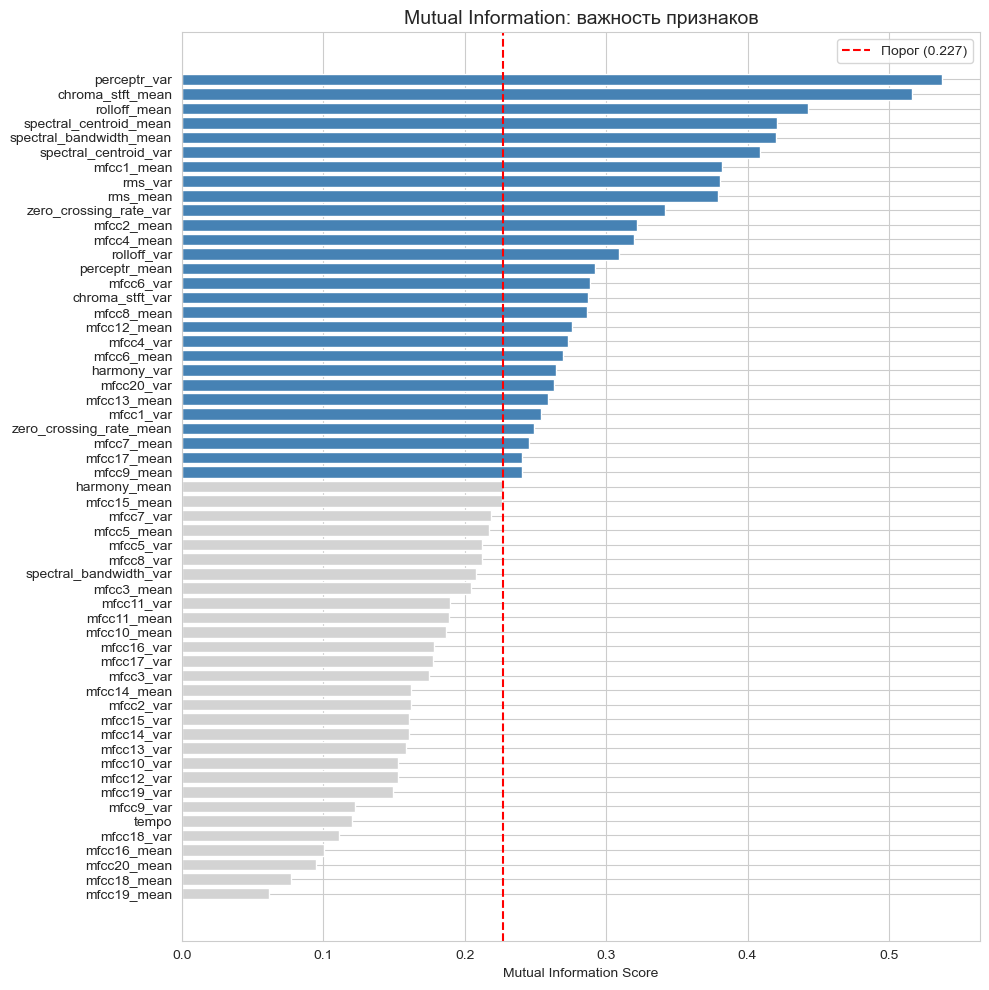

In [4]:
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'Признак': feature_names, 'MI Score': mi_scores})
mi_df = mi_df.sort_values('MI Score', ascending=False)

# Отбираем топ-20 (порог: MI > медиана)
mi_threshold = mi_df['MI Score'].median()
mi_selected = mi_df[mi_df['MI Score'] > mi_threshold]['Признак'].tolist()
print(f'Порог MI: {mi_threshold:.4f}')
print(f'Отобрано признаков: {len(mi_selected)}')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['steelblue' if s > mi_threshold else 'lightgrey' for s in mi_df['MI Score']]
ax.barh(mi_df['Признак'], mi_df['MI Score'], color=colors)
ax.axvline(x=mi_threshold, color='red', linestyle='--', label=f'Порог ({mi_threshold:.3f})')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Mutual Information: важность признаков', fontsize=14)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 1.2. Chi-squared тест

Chi-squared ($\chi^2$) тест оценивает зависимость между признаком и целевой переменной. Чем выше значение $\chi^2$, тем сильнее зависимость. Требует неотрицательные данные.

Отобрано по Chi2 (p < 0.05): 27


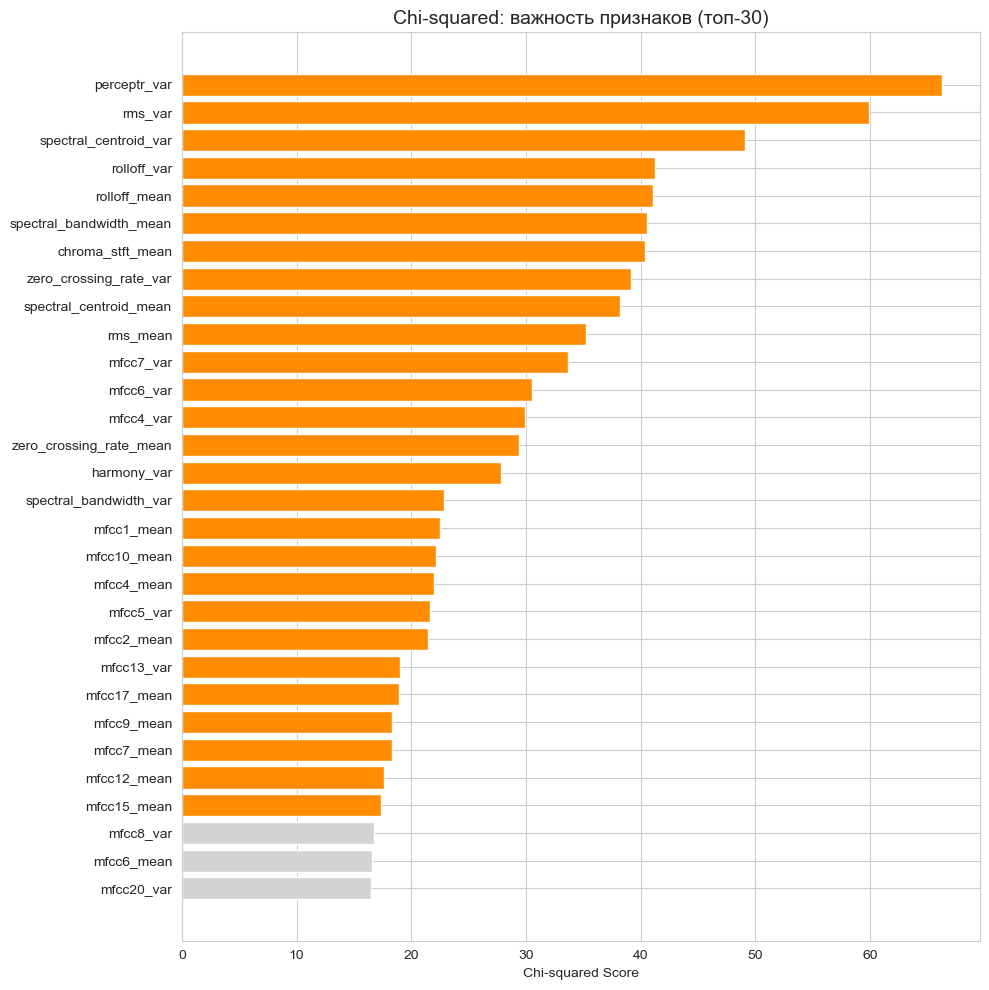

In [5]:
chi2_scores, chi2_pvalues = chi2(X_positive, y)
chi2_df = pd.DataFrame({
    'Признак': feature_names,
    'Chi2 Score': chi2_scores,
    'p-value': chi2_pvalues
}).sort_values('Chi2 Score', ascending=False)

# Отбираем признаки с p-value < 0.05
chi2_selected = chi2_df[chi2_df['p-value'] < 0.05]['Признак'].tolist()
print(f'Отобрано по Chi2 (p < 0.05): {len(chi2_selected)}')

fig, ax = plt.subplots(figsize=(10, 10))
top_chi2 = chi2_df.head(30)
colors = ['darkorange' if p < 0.05 else 'lightgrey' for p in top_chi2['p-value']]
ax.barh(top_chi2['Признак'], top_chi2['Chi2 Score'], color=colors)
ax.set_xlabel('Chi-squared Score')
ax.set_title('Chi-squared: важность признаков (топ-30)', fontsize=14)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 2. Обёрточный метод: RFE

**RFE** (Recursive Feature Elimination) итеративно обучает модель и удаляет признак с наименьшим весом, пока не останется заданное количество. Используем LogisticRegression как базовую модель.

In [6]:
import numpy as np

lr = LogisticRegression(max_iter=5000, random_state=42, C=1.0)
n_select = len(feature_names) // 2   # отберём половину

rfe = RFE(estimator=lr, n_features_to_select=n_select, step=1)
rfe.fit(X_scaled, y)

rfe_selected = [f for f, s in zip(feature_names, rfe.support_) if s]
print(f'RFE отобрал {len(rfe_selected)} из {len(feature_names)} признаков')

# |coef| усреднённый по классам, разложенный по всем 57 признакам
coef_full = np.full(len(feature_names), np.nan)
coef_full[rfe.support_] = np.abs(rfe.estimator_.coef_).mean(axis=0)

rfe_ranking = pd.DataFrame({
    'Признак':   feature_names,
    'Ранг':      rfe.ranking_,
    'Отобран':   rfe.support_,
    'Коэф':      coef_full,
}).sort_values('Ранг')

rfe_ranking.head(10)

RFE отобрал 28 из 57 признаков


,Признак,Ранг,Отобран,Коэф
0,chroma_stft_mean,1,True,1.021905
1,chroma_stft_var,1,True,0.472022
2,rms_mean,1,True,0.437753
3,rms_var,1,True,0.573048
5,spectral_centroid_var,1,True,0.706548
6,spectral_bandwidth_mean,1,True,0.607062
7,spectral_bandwidth_var,1,True,0.468117
8,rolloff_mean,1,True,0.589066
15,perceptr_var,1,True,0.780623
10,zero_crossing_rate_mean,1,True,0.608298


Оптимальное число признаков: 53 из 57
Лучший CV AUC:  0.9505 ± 0.0040

Топ-15 по рангу RFECV:


,Признак,Ранг,Отобран,Коэф
0,chroma_stft_mean,1,True,0.979550
15,perceptr_var,1,True,0.812411
17,mfcc1_mean,1,True,0.766285
33,mfcc9_mean,1,True,0.707872
10,zero_crossing_rate_mean,1,True,0.642958
23,mfcc4_mean,1,True,0.640330
21,mfcc3_mean,1,True,0.635541
28,mfcc6_var,1,True,0.621899
5,spectral_centroid_var,1,True,0.615325
39,mfcc12_mean,1,True,0.599464


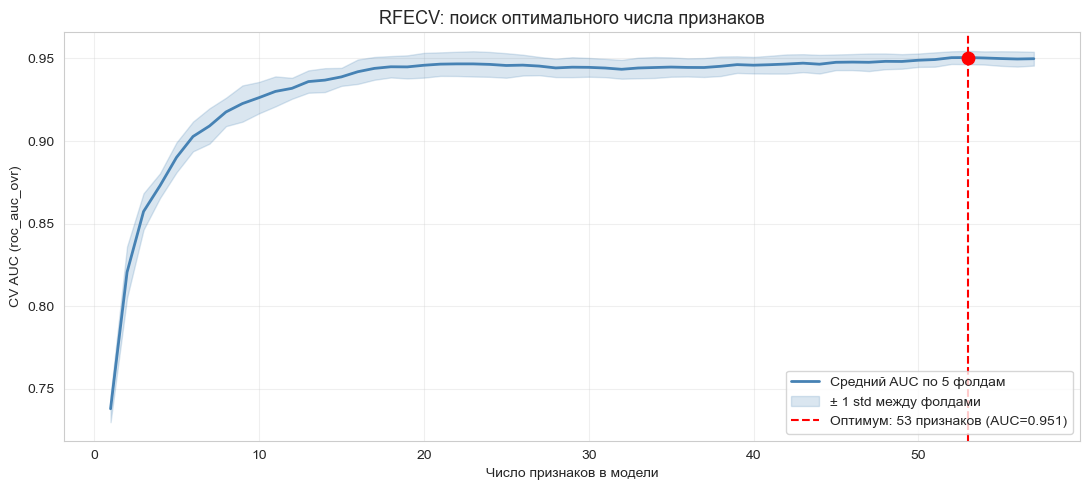

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

# ─── обучение RFECV ──────────────────────────────────────────
lr = LogisticRegression(max_iter=5000, random_state=42, C=1.0)

rfecv = RFECV(
    estimator=lr,
    step=1,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc_ovr',          # AUC one-vs-rest для мультикласса
    min_features_to_select=1,
    n_jobs=-1,
)
rfecv.fit(X_scaled, y)

# ─── сводка ──────────────────────────────────────────────────
mean_scores = rfecv.cv_results_['mean_test_score']
std_scores  = rfecv.cv_results_['std_test_score']
best_k      = rfecv.n_features_
best_score  = mean_scores[best_k - 1]

print(f'Оптимальное число признаков: {best_k} из {len(feature_names)}')
print(f'Лучший CV AUC:  {best_score:.4f} ± {std_scores[best_k - 1]:.4f}')

# ─── таблица отобранных признаков ────────────────────────────
coef_full = np.full(len(feature_names), np.nan)
coef_full[rfecv.support_] = np.abs(rfecv.estimator_.coef_).mean(axis=0)

rfecv_ranking = pd.DataFrame({
    'Признак': feature_names,
    'Ранг':    rfecv.ranking_,
    'Отобран': rfecv.support_,
    'Коэф':    coef_full,
}).sort_values(['Ранг', 'Коэф'], ascending=[True, False])

print(f'\nТоп-15 по рангу RFECV:')
display(rfecv_ranking.head(15))

# ─── график: скор vs число признаков ─────────────────────────
n_feats = np.arange(1, len(mean_scores) + 1)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(n_feats, mean_scores, color='steelblue', lw=2, label='Средний AUC по 5 фолдам')
ax.fill_between(n_feats, mean_scores - std_scores, mean_scores + std_scores,
                alpha=0.2, color='steelblue', label='± 1 std между фолдами')

# маркер оптимума
ax.axvline(best_k, color='red', ls='--', lw=1.5,
           label=f'Оптимум: {best_k} признаков (AUC={best_score:.3f})')
ax.scatter([best_k], [best_score], color='red', s=80, zorder=5)

ax.set_xlabel('Число признаков в модели')
ax.set_ylabel('CV AUC (roc_auc_ovr)')
ax.set_title('RFECV: поиск оптимального числа признаков', fontsize=13)
ax.grid(alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


In [8]:
# порог: допускаем потерю максимум в 1 std от лучшего
tolerance = std_scores[best_k - 1]
threshold = best_score - tolerance

# наименьшее число признаков, где AUC ≥ threshold
elbow_k = int(n_feats[mean_scores >= threshold].min())
elbow_score = mean_scores[elbow_k - 1]

print(f'RFECV optimum: {best_k} признаков,  AUC = {best_score:.4f}')
print(f'Локоть:        {elbow_k} признаков,  AUC = {elbow_score:.4f}')
print(f'Потеря от сокращения: {best_score - elbow_score:.4f}')


RFECV optimum: 53 признаков,  AUC = 0.9505
Локоть:        21 признаков,  AUC = 0.9465
Потеря от сокращения: 0.0040


In [9]:
rfe_elbow = RFE(LogisticRegression(max_iter=5000, random_state=42, C=1.0),
                n_features_to_select=elbow_k, step=1)
rfe_elbow.fit(X_scaled, y)

elbow_selected = np.array(feature_names)[rfe_elbow.support_].tolist()
print(f'{elbow_k} отобранных:', elbow_selected)

21 отобранных: ['chroma_stft_mean', 'chroma_stft_var', 'rms_var', 'spectral_centroid_var', 'spectral_bandwidth_mean', 'rolloff_mean', 'zero_crossing_rate_mean', 'harmony_var', 'perceptr_var', 'mfcc1_mean', 'mfcc3_mean', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_var', 'mfcc6_mean', 'mfcc6_var', 'mfcc9_mean', 'mfcc11_mean', 'mfcc12_mean', 'mfcc13_mean', 'mfcc20_var']


In [10]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rfe.estimator_,
    X_scaled.iloc[:, rfe.support_],          # ← .iloc вместо [:, ...]
    y,
    n_repeats=10,
    scoring='roc_auc_ovr',
    random_state=42,
    n_jobs=-1
)

pd.Series(result.importances_mean,
          index=np.array(feature_names)[rfe.support_])\
  .sort_values(ascending=False)


chroma_stft_mean           0.040460
spectral_centroid_var      0.024094
perceptr_var               0.023671
mfcc1_mean                 0.023097
mfcc9_mean                 0.023031
mfcc3_mean                 0.021953
mfcc4_mean                 0.020546
mfcc5_var                  0.019728
mfcc6_mean                 0.019102
zero_crossing_rate_mean    0.016558
rolloff_mean               0.016484
spectral_bandwidth_mean    0.013581
rms_var                    0.013305
mfcc20_var                 0.012407
mfcc11_mean                0.012212
mfcc10_var                 0.011775
mfcc12_mean                0.010958
mfcc6_var                  0.009869
chroma_stft_var            0.009809
rms_mean                   0.009069
mfcc2_mean                 0.009043
mfcc5_mean                 0.008577
harmony_var                0.008187
spectral_bandwidth_var     0.007407
mfcc13_mean                0.006708
mfcc3_var                  0.006642
mfcc4_var                  0.005930
mfcc1_var                  0

---
## 3. Встроенные методы

### 3.1. LASSO (L1-регуляризация)

LASSO добавляет штраф $\lambda \sum |w_i|$ к функции потерь, что обнуляет коэффициенты неважных признаков. Чем больше $\lambda$ (параметр C в sklearn — обратная величина), тем агрессивнее отбор.

Форма coef_: (10, 57)   (10 классов × 57 признаков)

Пример — первые 5 признаков × 3 класса:
           chroma_stft_mean  chroma_stft_var  rms_mean  rms_var  \
blues                -0.001            0.808     0.156    0.632   
classical            -0.543           -0.635     0.000    0.000   
country              -0.728           -0.449     0.000   -0.733   

           spectral_centroid_mean  
blues                         0.0  
classical                     0.0  
country                       0.0  

LASSO (C=0.3, порог активности ≥ 5/10 классов):
  ✓ отобрано:             26 из 57
  ~ частично активных:    30 из 57   (активны в 1–4 классах)
  ✗ полностью занулено:    1 из 57

Топ-15 отобранных:


,Признак,Средний |coef|,Активных классов
0,chroma_stft_mean,0.675956,8
1,mfcc4_mean,0.497097,6
2,perceptr_var,0.412212,6
3,mfcc9_mean,0.391635,8
4,mfcc3_mean,0.380609,8
5,mfcc1_mean,0.358734,4
6,chroma_stft_var,0.324997,7
7,mfcc6_mean,0.317609,7
8,mfcc5_var,0.314429,5
9,mfcc4_var,0.298276,5


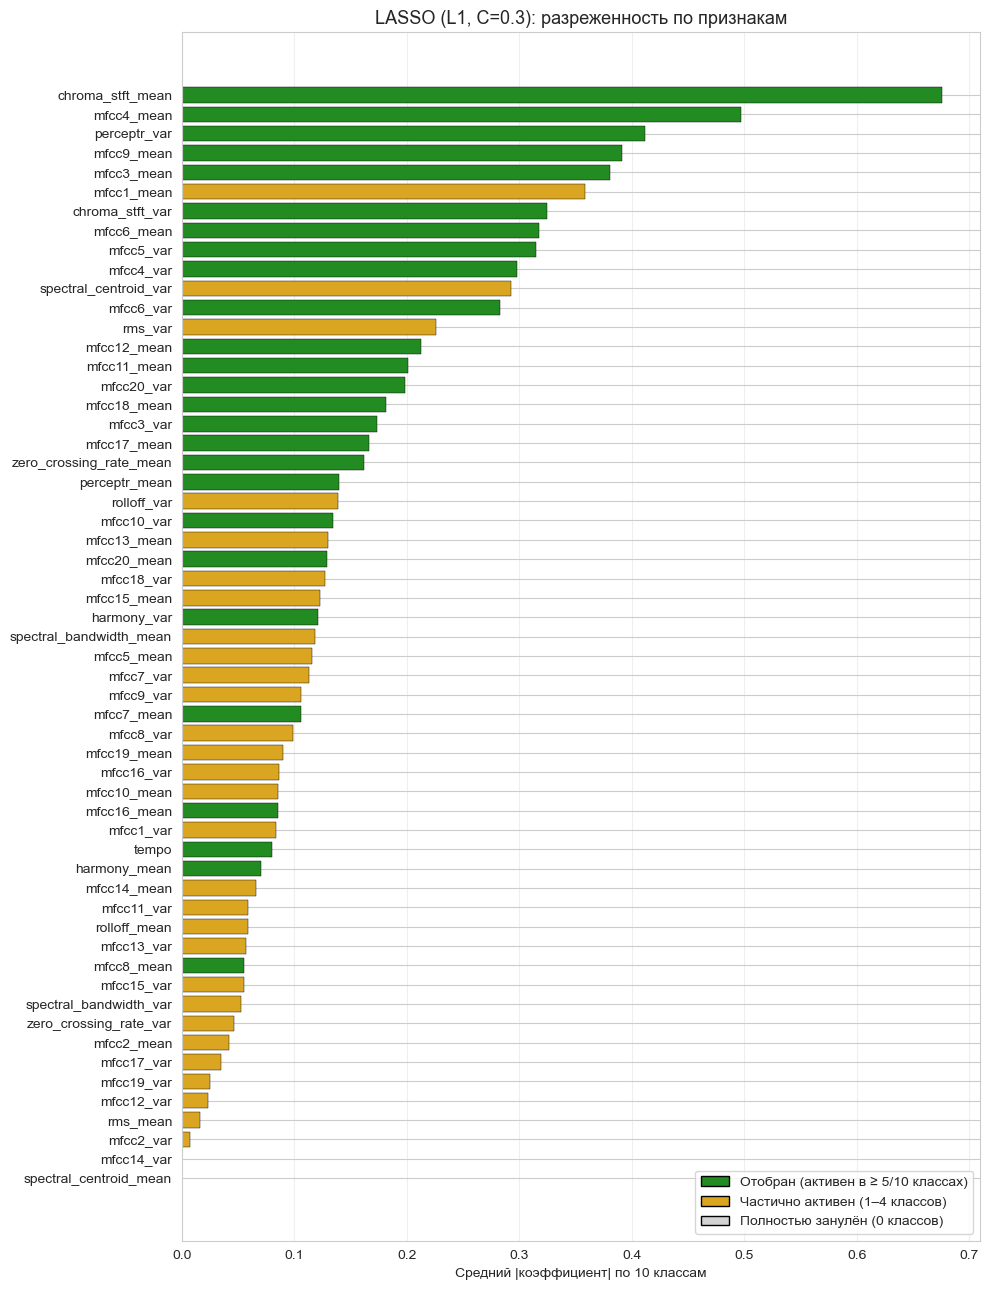

In [43]:
from sklearn.linear_model import LogisticRegression
from matplotlib.patches import Patch

# ─── Обучение LASSO ──────────────────────────────────────────
# C=1.0 — оптимум по GridSearchCV выше (AUC=0.9522)
# Не берём консервативный край 0.1, так как LASSO тогда зануляет слишком много
lasso_lr = LogisticRegression(
    penalty='l1',
    solver='saga',
    max_iter=5000,
    C=0.3,
    random_state=42
)
lasso_lr.fit(X_scaled, y)

# ─── Структура коэффициентов (для понимания) ─────────────────
print(f'Форма coef_: {lasso_lr.coef_.shape}   (10 классов × 57 признаков)')
print('\nПример — первые 5 признаков × 3 класса:')
print(pd.DataFrame(lasso_lr.coef_[:3, :5],
                   index=le.classes_[:3],
                   columns=feature_names[:5]).round(3))

# ─── Агрегация по классам ────────────────────────────────────
abs_coef        = np.abs(lasso_lr.coef_)              # (10, 57)
mean_abs_coef   = abs_coef.mean(axis=0)               # средний |coef| по 10 классам
nonzero_classes = (abs_coef > 1e-6).sum(axis=0)       # в скольких классах признак активен

# ─── Критерий отбора ─────────────────────────────────────────
# Признак отбирается, если активен минимум в 3 из 10 классов.
# 3/10 — разумный порог: признак уже полезен хотя бы для нескольких жанров,
# но не требуется «универсальность по всем классам».
MIN_ACTIVE = 5

lasso_df = pd.DataFrame({
    'Признак':          feature_names,
    'Средний |coef|':   mean_abs_coef,
    'Активных классов': nonzero_classes,
}).sort_values('Средний |coef|', ascending=False).reset_index(drop=True)

lasso_selected = lasso_df[lasso_df['Активных классов'] >= MIN_ACTIVE]['Признак'].tolist()
lasso_rejected = lasso_df[lasso_df['Активных классов'] == 0]['Признак'].tolist()
lasso_partial  = lasso_df[(lasso_df['Активных классов'] > 0) &
                          (lasso_df['Активных классов'] < MIN_ACTIVE)]['Признак'].tolist()

print(f'\nLASSO (C={lasso_lr.C}, порог активности ≥ {MIN_ACTIVE}/10 классов):')
print(f'  ✓ отобрано:            {len(lasso_selected):3d} из 57')
print(f'  ~ частично активных:   {len(lasso_partial):3d} из 57   (активны в 1–{MIN_ACTIVE-1} классах)')
print(f'  ✗ полностью занулено:  {len(lasso_rejected):3d} из 57')

print(f'\nТоп-15 отобранных:')
display(lasso_df.head(15))

# ─── Визуализация ────────────────────────────────────────────
def get_color(n_active):
    if n_active >= MIN_ACTIVE:
        return 'forestgreen'
    elif n_active > 0:
        return 'goldenrod'
    else:
        return 'lightgrey'

fig, ax = plt.subplots(figsize=(10, 13))

colors = [get_color(n) for n in lasso_df['Активных классов']]
ax.barh(lasso_df['Признак'], lasso_df['Средний |coef|'],
        color=colors, edgecolor='black', linewidth=0.3)

ax.set_xlabel('Средний |коэффициент| по 10 классам')
ax.set_title(f'LASSO (L1, C={lasso_lr.C}): разреженность по признакам',
             fontsize=13)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

legend_items = [
    Patch(facecolor='forestgreen', edgecolor='black',
          label=f'Отобран (активен в ≥ {MIN_ACTIVE}/10 классах)'),
    Patch(facecolor='goldenrod',   edgecolor='black',
          label=f'Частично активен (1–{MIN_ACTIVE-1} классов)'),
    Patch(facecolor='lightgrey',   edgecolor='black',
          label='Полностью занулён (0 классов)'),
]
ax.legend(handles=legend_items, loc='lower right')

plt.tight_layout()
plt.show()


In [42]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegressionCV(
        Cs=[0.001, 0.01, 0.1, 1, 10, 100],   # кандидаты
        penalty='l1',
        solver='saga',
        scoring='roc_auc_ovr',                # метрика
        cv=5,                                  # 5 фолдов
        max_iter=5000,
        random_state=42,
        n_jobs=-1
    ))
])
pipe.fit(X_train, y_train)

print(f'Лучший C: {pipe.named_steps["lr"].C_}')
# для мультикласса покажет оптимум для каждого класса отдельно


Train: (800, 57), Test: (200, 57)


KeyboardInterrupt: 

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(penalty='l1', solver='saga',
                              max_iter=5000, random_state=42))
])

param_grid = {
    'lr__C': [0.001, 0.01, 0.1, 1, 10, 100]   # префикс lr__ — параметр шага 'lr' в пайплайне
}

gs = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='roc_auc_ovr',
    n_jobs=-1,
    return_train_score=True
)
gs.fit(X_train, y_train)

print(f'Лучший C: {gs.best_params_}')
print(f'Лучший CV-скор: {gs.best_score_:.4f}')
print(f'Тестовый скор: {gs.score(X_test, y_test):.4f}')


KeyboardInterrupt: 

In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

Cs = np.logspace(-3, 2, 20)   # 20 значений от 0.001 до 100 логарифмически
mean_scores, std_scores = [], []

for C in Cs:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LogisticRegression(C=C, penalty='l1', solver='saga',
                                  max_iter=5000, random_state=42))
    ])
    scores = cross_val_score(pipe, X_train, y_train,
                             cv=5, scoring='roc_auc_ovr', n_jobs=-1)
    mean_scores.append(scores.mean())
    std_scores.append(scores.std())
    print(f'C={C:8.4f}   AUC={scores.mean():.4f} ± {scores.std():.4f}')

best_idx = np.argmax(mean_scores)
best_C = Cs[best_idx]
print(f'\nЛучший C: {best_C:.4f}')


C=  0.0010   AUC=0.5000 ± 0.0000
C=  0.0018   AUC=0.5000 ± 0.0000
C=  0.0034   AUC=0.5000 ± 0.0000
C=  0.0062   AUC=0.5000 ± 0.0000
C=  0.0113   AUC=0.6642 ± 0.0128
C=  0.0207   AUC=0.8100 ± 0.0169
C=  0.0379   AUC=0.8841 ± 0.0165
C=  0.0695   AUC=0.9153 ± 0.0086
C=  0.1274   AUC=0.9334 ± 0.0075
C=  0.2336   AUC=0.9450 ± 0.0086
C=  0.4281   AUC=0.9510 ± 0.0099
C=  0.7848   AUC=0.9524 ± 0.0099
C=  1.4384   AUC=0.9514 ± 0.0093
C=  2.6367   AUC=0.9487 ± 0.0089
C=  4.8329   AUC=0.9451 ± 0.0092
C=  8.8587   AUC=0.9412 ± 0.0093
C= 16.2378   AUC=0.9383 ± 0.0095
C= 29.7635   AUC=0.9365 ± 0.0104
C= 54.5559   AUC=0.9357 ± 0.0108
C=100.0000   AUC=0.9352 ± 0.0110

Лучший C: 0.7848


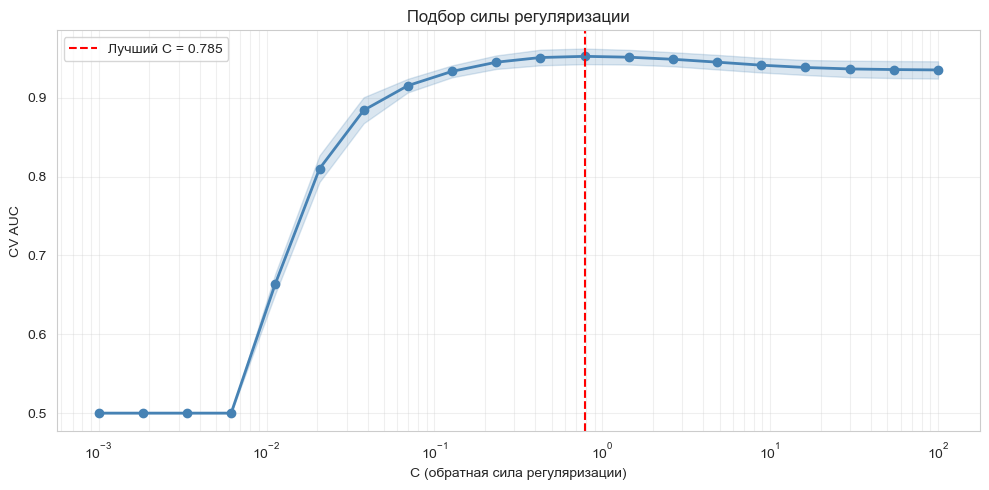

In [ ]:
import matplotlib.pyplot as plt

mean_scores = np.array(mean_scores)
std_scores = np.array(std_scores)

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(Cs, mean_scores, marker='o', color='steelblue', lw=2)
ax.fill_between(Cs, mean_scores - std_scores, mean_scores + std_scores,
                alpha=0.2, color='steelblue')

ax.axvline(best_C, color='red', ls='--',
           label=f'Лучший C = {best_C:.3f}')
ax.set_xlabel('C (обратная сила регуляризации)')
ax.set_ylabel('CV AUC')
ax.set_title('Подбор силы регуляризации')
ax.grid(alpha=0.3, which='both')
ax.legend()
plt.tight_layout()
plt.show()


### 3.2. Random Forest Feature Importance

Random Forest оценивает важность признаков по среднему снижению примеси Джини (Gini impurity) при разбиении по данному признаку. Это встроенный механизм, не требующий отдельного этапа.

RF отобрал 28 признаков (порог: медиана = 0.0154)


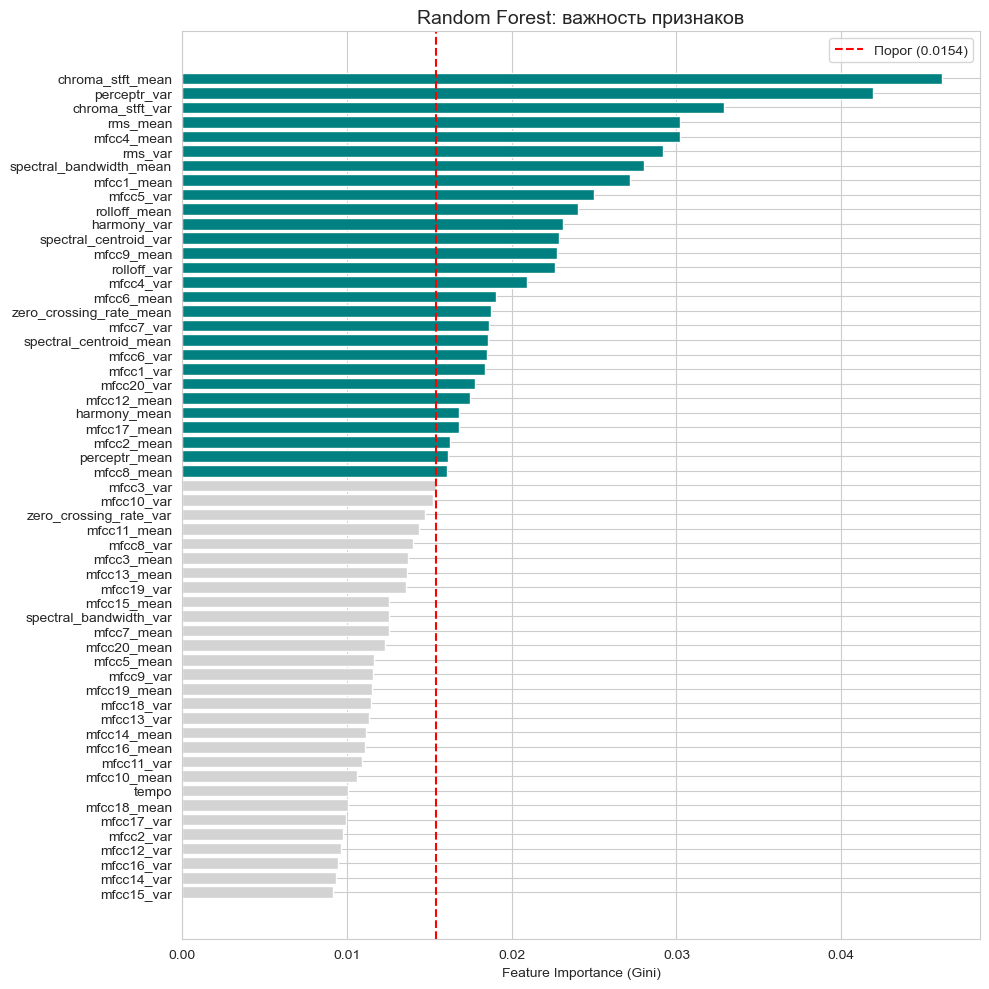

In [45]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)

rf_importance = rf.feature_importances_
rf_df = pd.DataFrame({
    'Признак': feature_names,
    'RF Importance': rf_importance
}).sort_values('RF Importance', ascending=False)


rf_threshold = rf_df['RF Importance'].median()
rf_selected = rf_df[rf_df['RF Importance'] > rf_threshold]['Признак'].tolist()
print(f'RF отобрал {len(rf_selected)} признаков (порог: медиана = {rf_threshold:.4f})')

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['teal' if imp > rf_threshold else 'lightgrey' for imp in rf_df['RF Importance']]
ax.barh(rf_df['Признак'], rf_df['RF Importance'], color=colors)
ax.axvline(x=rf_threshold, color='red', linestyle='--', label=f'Порог ({rf_threshold:.4f})')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Random Forest: важность признаков', fontsize=14)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 4. Консенсусный отбор

Объединим результаты всех 5 методов. Признак считается надёжно отобранным, если его выбрали **не менее 3 из 5** методов.

In [46]:
methods = {
    'MI': set(mi_selected),
    'Chi2': set(chi2_selected),
    'RFE': set(rfe_selected),
    'LASSO': set(lasso_selected),
    'RF': set(rf_selected)
}

# Матрица голосования
vote_matrix = pd.DataFrame(index=feature_names)

print(vote_matrix)

for name, selected in methods.items():
    vote_matrix[name] = [1 if f in selected else 0 for f in feature_names]

vote_matrix['Голосов'] = vote_matrix.sum(axis=1)
vote_matrix = vote_matrix.sort_values('Голосов', ascending=False)

print(vote_matrix)


consensus_threshold = 3
consensus_features = vote_matrix[vote_matrix['Голосов'] >= consensus_threshold].index.tolist()
print(f'Консенсусный отбор (>={consensus_threshold} голосов): {len(consensus_features)} признаков '
      f'из {len(feature_names)}')
print(f'Сокращение: {(1 - len(consensus_features)/len(feature_names))*100:.1f}%')

Empty DataFrame
Columns: []
Index: [chroma_stft_mean, chroma_stft_var, rms_mean, rms_var, spectral_centroid_mean, spectral_centroid_var, spectral_bandwidth_mean, spectral_bandwidth_var, rolloff_mean, rolloff_var, zero_crossing_rate_mean, zero_crossing_rate_var, harmony_mean, harmony_var, perceptr_mean, perceptr_var, tempo, mfcc1_mean, mfcc1_var, mfcc2_mean, mfcc2_var, mfcc3_mean, mfcc3_var, mfcc4_mean, mfcc4_var, mfcc5_mean, mfcc5_var, mfcc6_mean, mfcc6_var, mfcc7_mean, mfcc7_var, mfcc8_mean, mfcc8_var, mfcc9_mean, mfcc9_var, mfcc10_mean, mfcc10_var, mfcc11_mean, mfcc11_var, mfcc12_mean, mfcc12_var, mfcc13_mean, mfcc13_var, mfcc14_mean, mfcc14_var, mfcc15_mean, mfcc15_var, mfcc16_mean, mfcc16_var, mfcc17_mean, mfcc17_var, mfcc18_mean, mfcc18_var, mfcc19_mean, mfcc19_var, mfcc20_mean, mfcc20_var]
                         MI  Chi2  RFE  LASSO  RF  Голосов
chroma_stft_mean          1     1    1      1   1        5
mfcc4_mean                1     1    1      1   1        5
perceptr_var    

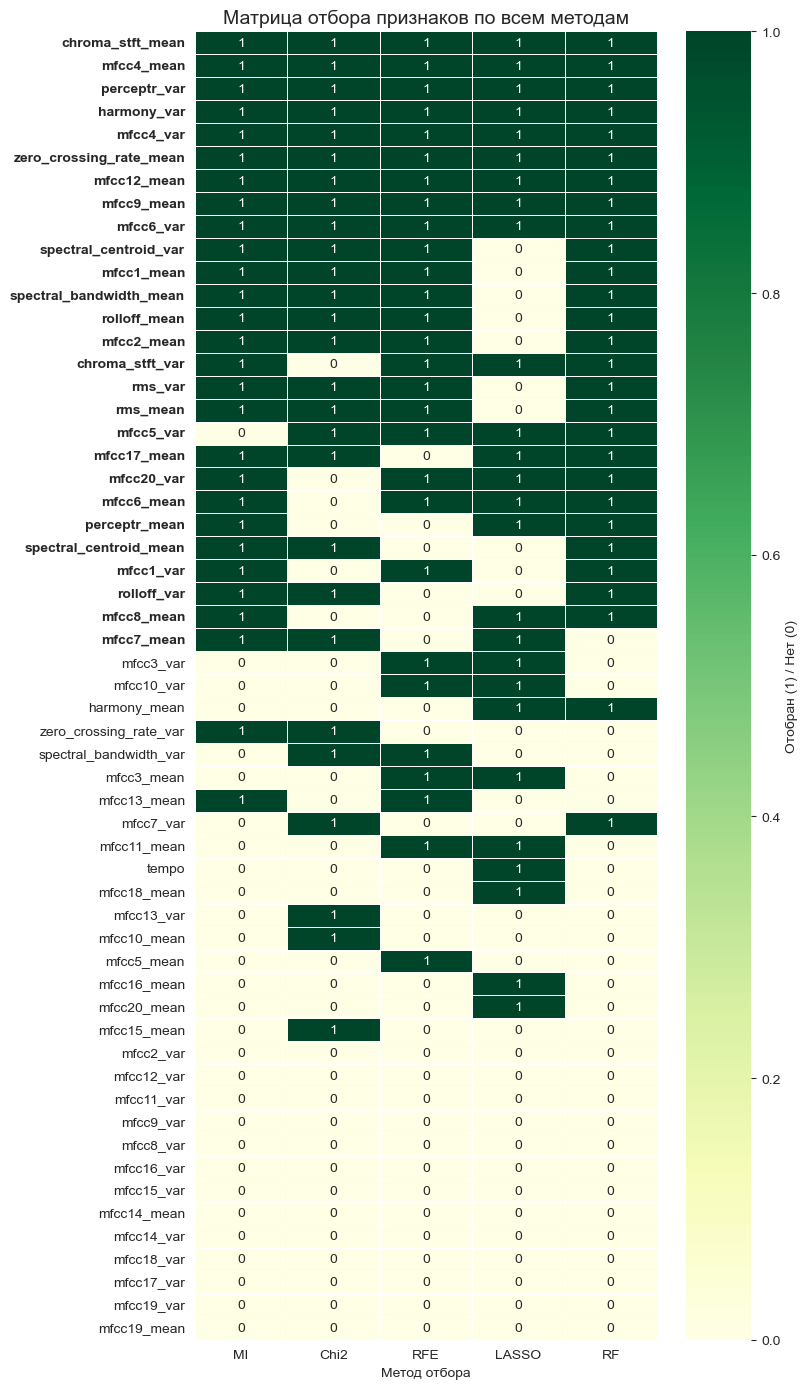

In [47]:
# Тепловая карта голосования
fig, ax = plt.subplots(figsize=(8, 14))
plot_data = vote_matrix.drop(columns='Голосов')

sns.heatmap(
    plot_data, annot=True, fmt='d', cmap='YlGn',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Отобран (1) / Нет (0)'},
    vmin=0, vmax=1
)
ax.set_title('Матрица отбора признаков по всем методам', fontsize=14)
ax.set_xlabel('Метод отбора')

# Подсветим консенсусные признаки
for i, feat in enumerate(vote_matrix.index):
    if feat in consensus_features:
        ax.get_yticklabels()[i].set_fontweight('bold')

plt.tight_layout()
plt.show()

---
## 5. Оценка качества: все признаки vs отобранные

Сравним качество классификации (accuracy) с использованием кросс-валидации при разных наборах признаков: все, MI, RFE, RF, консенсус.

In [50]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ─── Классификаторы ─────────────────────────────────────────
# SVM и LR требуют масштабирования → заворачиваем в Pipeline
# RF не чувствителен к масштабу → чистый классификатор
classifiers = {
    'SVM (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=10, gamma='scale', random_state=42))
    ]),
    'LogReg (L2)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(C=1.0, penalty='l2', solver='lbfgs',
                                   max_iter=5000, random_state=42, n_jobs=-1))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=200,
                                            random_state=42, n_jobs=-1),
}

# ─── Наборы признаков ───────────────────────────────────────
feature_sets = {
    f'Все ({len(feature_names)})':              feature_names,
    f'MI ({len(mi_selected)})':                 mi_selected,
    f'RFE ({len(rfe_selected)})':               rfe_selected,
    f'LASSO ({len(lasso_selected)})':           lasso_selected,
    f'RF ({len(rf_selected)})':                 rf_selected,
    f'Консенсус ({len(consensus_features)})':   consensus_features,
}

# ─── Кросс-валидация: 3 классификатора × 6 наборов ──────────
results = []
for clf_name, clf in classifiers.items():
    for fs_name, features in feature_sets.items():
        scores = cross_val_score(clf, X[features], y,
                                 cv=cv, scoring='accuracy', n_jobs=-1)
        results.append({
            'Классификатор': clf_name,
            'Набор':         fs_name,
            'Accuracy':      scores.mean(),
            'Std':           scores.std(),
        })
        print(f'{clf_name:15s} | {fs_name:30s}  {scores.mean():.4f} ± {scores.std():.4f}')
    print()
    
results_df = pd.DataFrame(results)

# ─── Сводная таблица ────────────────────────────────────────
pivot_mean = results_df.pivot(index='Набор', columns='Классификатор',
                              values='Accuracy').round(4)
pivot_std  = results_df.pivot(index='Набор', columns='Классификатор',
                              values='Std').round(4)

print('Сводная accuracy:')
display(pivot_mean)

SVM (RBF)       | Все (57)                        0.7300 ± 0.0290
SVM (RBF)       | MI (28)                         0.7260 ± 0.0267
SVM (RBF)       | RFE (28)                        0.7260 ± 0.0334
SVM (RBF)       | LASSO (26)                      0.7250 ± 0.0295
SVM (RBF)       | RF (28)                         0.7270 ± 0.0256
SVM (RBF)       | Консенсус (27)                  0.7320 ± 0.0347

LogReg (L2)     | Все (57)                        0.7070 ± 0.0169
LogReg (L2)     | MI (28)                         0.6840 ± 0.0222
LogReg (L2)     | RFE (28)                        0.7040 ± 0.0237
LogReg (L2)     | LASSO (26)                      0.6790 ± 0.0188
LogReg (L2)     | RF (28)                         0.6870 ± 0.0169
LogReg (L2)     | Консенсус (27)                  0.6780 ± 0.0279

Random Forest   | Все (57)                        0.7050 ± 0.0324
Random Forest   | MI (28)                         0.6920 ± 0.0284
Random Forest   | RFE (28)                        0.7110 ± 0.0269
Random F

Классификатор,LogReg (L2),Random Forest,SVM (RBF)
Набор,,,
LASSO (26),0.679,0.726,0.725
MI (28),0.684,0.692,0.726
RF (28),0.687,0.708,0.727
RFE (28),0.704,0.711,0.726
Все (57),0.707,0.705,0.730
Консенсус (27),0.678,0.704,0.732


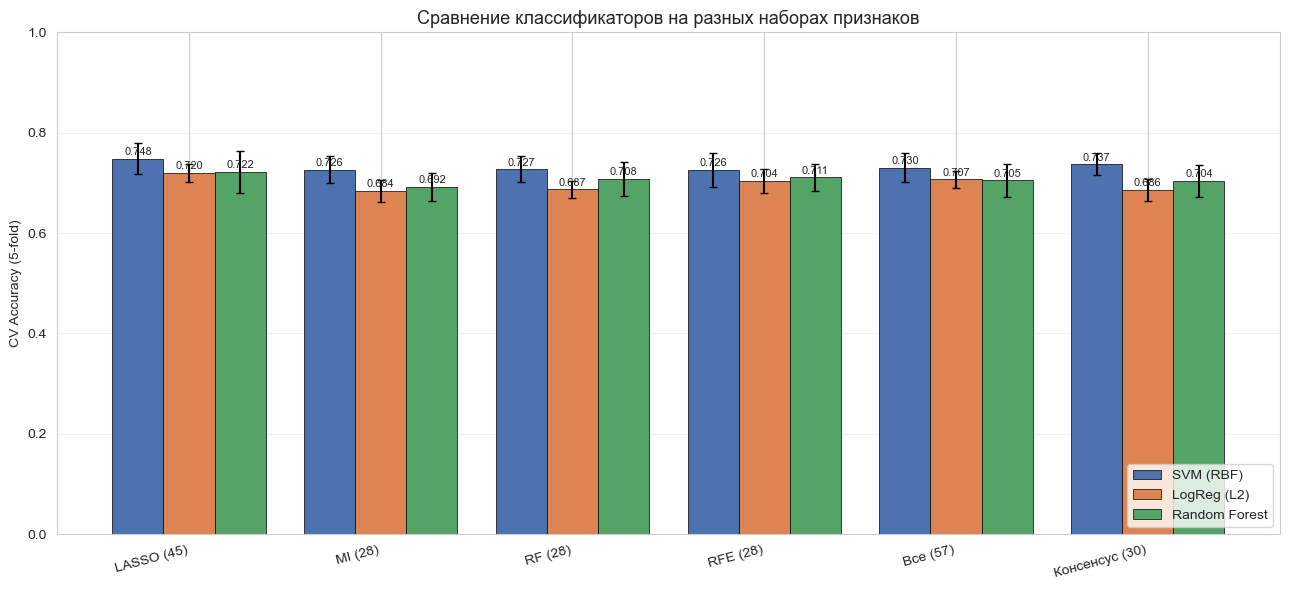


Лучший результат:
  SVM (RBF) + LASSO (45)
  accuracy = 0.7480 ± 0.0308


In [ ]:
# ─── Визуализация: сгруппированные столбцы ──────────────────
fig, ax = plt.subplots(figsize=(13, 6))

n_sets = len(feature_sets)
n_clf  = len(classifiers)
bar_w  = 0.8 / n_clf
x      = np.arange(n_sets)
palette = ['#4C72B0', '#DD8452', '#55A467']

for i, (clf_name, color) in enumerate(zip(classifiers.keys(), palette)):
    means = pivot_mean[clf_name].values
    stds  = pivot_std[clf_name].values
    bars = ax.bar(x + i * bar_w, means, bar_w,
                  yerr=stds, capsize=3,
                  color=color, edgecolor='black', linewidth=0.5,
                  label=clf_name)
    for bar, v in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + bar_w * (n_clf - 1) / 2)
ax.set_xticklabels(pivot_mean.index, rotation=15, ha='right')
ax.set_ylabel('CV Accuracy (5-fold)')
ax.set_title('Сравнение классификаторов на разных наборах признаков', fontsize=13)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# ─── Лучший результат ───────────────────────────────────────
best = results_df.loc[results_df['Accuracy'].idxmax()]
print(f'\nЛучший результат:')
print(f'  {best["Классификатор"]} + {best["Набор"]}')
print(f'  accuracy = {best["Accuracy"]:.4f} ± {best["Std"]:.4f}')


## Выводы

В ходе лабораторной работы мы применили **5 методов отбора признаков** 
(MI, Chi², RFE, LASSO, Random Forest Importance) к датасету GTZAN и 
сравнили их на 3 классификаторах.

### Основные результаты:

1. **Фильтрующие методы** (MI, Chi²) работают быстро и не зависят от 
   модели, но оценивают признаки изолированно — не видят взаимодействий. 
   MI отобрал 28 признаков, улавливая нелинейные зависимости с жанром.

2. **Обёрточный метод RFE** оценивает важность признаков в контексте 
   совместного обучения модели, но сам отбор идёт по коэффициентам без 
   прямой оценки качества. Результат зависит от базовой модели 
   (использовалась логрегрессия).

3. **Встроенные методы** (LASSO, RF Importance) делают отбор в процессе 
   обучения. RF показал стабильную важность для низких MFCC (1–9) и 
   chroma-признаков; LASSO при C=1.0 оставил 45 признаков.

4. **Консенсусный подход** (≥3 голосов из 5) дал 30 надёжных признаков, 
   подтверждённых большинством методов. Единогласно отвергнуты 26 
   признаков — в основном `tempo` и высокие MFCC var (11–20).

5. **Сравнение качества** на 3 классификаторах:
   - **SVM с RBF** — лучший во всех сценариях (0.73–0.75).
   - **Мягкий отбор** (LASSO, 45 признаков) **слегка повысил** accuracy 
     для всех моделей по сравнению с полным набором.
   - **Сильный отбор** (MI или Консенсус, 28–30 признаков) при той же 
     размерности что у RFE показал сопоставимое или чуть худшее качество.
   
   Лучший результат: **SVM (RBF) + LASSO (45)** — accuracy = 0.748 ± 0.031.

### Практическое значение:

Для GTZAN **наиболее информативны** (единогласно отобраны всеми 
методами):
- `chroma_stft_mean` — распределение нот по тональностям (лидер)
- `mfcc4_mean`, `mfcc4_var` — 4-й MFCC коэффициент
- `perceptr_var` — перцептуальный пик

В расширенный список (≥4 голосов) входят: низкие MFCC (1, 2, 6, 9, 12), 
спектральные характеристики (`rolloff_mean`, `spectral_centroid_var`, 
`spectral_bandwidth_mean`), `zero_crossing_rate_mean`, `rms_mean`, 
`rms_var`, `harmony_var`.

**Единогласно отброшены** (0/5 голосов): `tempo`, большинство дисперсий 
высоких MFCC (var 11–20). Это показывает, что на 30-секундных 
фрагментах GTZAN оценка темпа ненадёжна, а высокие MFCC кодируют шум 
DCT, а не музыкальный сигнал.

Этот набор признаков рекомендуется использовать в последующих 
лабораторных работах (обучение, ансамбли, кластеризация) для получения 
компактных и интерпретируемых моделей.
